In [1]:
import os
import sys
sys.path.insert(0, os.path.abspath(".."))
import config
from src.utils import smooth
import matplotlib.pyplot as plt
import numpy as np
import glob
import json


In [2]:
# get metrics dir
root_dir = os.path.abspath(os.path.join(os.getcwd(), ".."))
metrics_dir = os.path.join(root_dir, "metrics", "*.json")
files = glob.glob(metrics_dir)

print(f"Root dir: {root_dir}")
print(f"Files: {files}")

# store runs
runs = []
for file in files:
    with open(file) as f:
        runs.append(json.load(f))

Root dir: /home/gperegoy/ppo_learning
Files: ['/home/gperegoy/ppo_learning/metrics/HalfCheetah-v5_lr0.0001_layers[256, 256]_k10.json', '/home/gperegoy/ppo_learning/metrics/HalfCheetah-v5_lr0.001_layers[256, 256]_k10.json', '/home/gperegoy/ppo_learning/metrics/HalfCheetah-v5_lr0.0003_layers[256, 256]_k20.json', '/home/gperegoy/ppo_learning/metrics/HalfCheetah-v5_lr0.0001_layers[256, 256]_k20.json', '/home/gperegoy/ppo_learning/metrics/HalfCheetah-v5_lr0.0003_layers[256, 256]_k10.json', '/home/gperegoy/ppo_learning/metrics/HalfCheetah-v5_lr0.0001_layers[64, 64]_k20.json', '/home/gperegoy/ppo_learning/metrics/HalfCheetah-v5_lr0.0003_layers[256, 256]_k15.json', '/home/gperegoy/ppo_learning/metrics/HalfCheetah-v5_lr0.0003_layers[64, 64]_k10.json', '/home/gperegoy/ppo_learning/metrics/HalfCheetah-v5_lr0.0003_layers[128, 128]_k10.json']


In [ ]:
# organize runs
best_runs = [r for r in runs if r['lr'] == 1e-4 and r['k_epochs'] == 20]
lr_runs = [r for r in runs if r['lr'] != config.BASELINE['lr'] and r not in best_runs]
k_runs = [r for r in runs if r['k_epochs'] != config.BASELINE['k_epochs'] and r not in best_runs]
layer_runs = [r for r in runs if r['actor_layer_sizes'] != config.BASELINE['actor_layer_sizes'] and r not in best_runs]
base_run = [r for r in runs if r not in lr_runs + k_runs + layer_runs + best_runs]

2


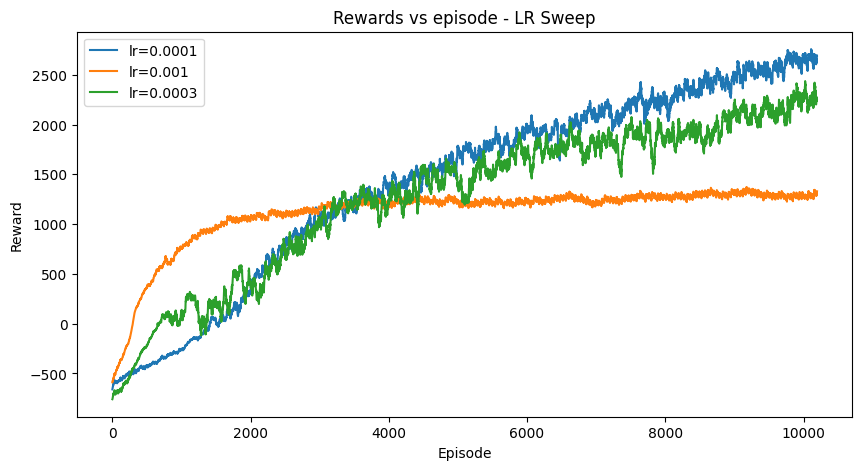

In [4]:
# plot lr runs
plt.figure(figsize=(10, 5))

for run in lr_runs:
    plt.plot(smooth(run['rewards']), label=f"lr={run['lr']}")
plt.plot(smooth(base_run[0]['rewards']), label=f"lr={base_run[0]['lr']}")
plt.title(f"Rewards vs episode - LR Sweep")
plt.xlabel("Episode")
plt.ylabel("Reward")
plt.legend()
plt.show()

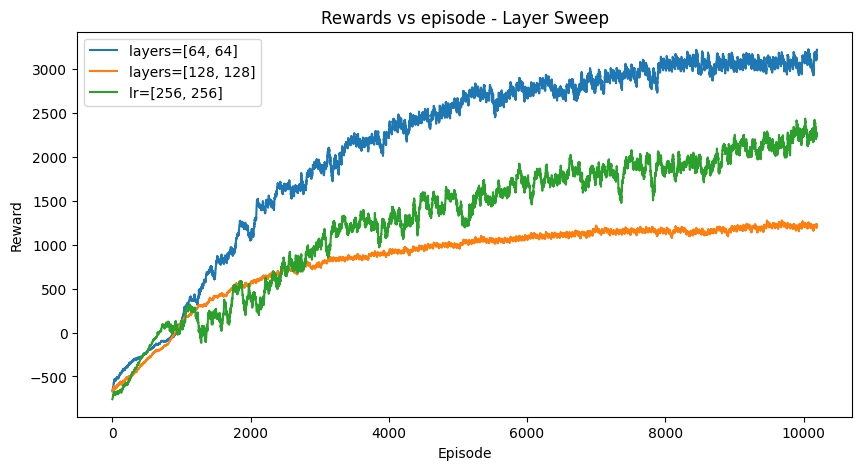

In [5]:
# plot layer runs
plt.figure(figsize=(10, 5))

for run in layer_runs:
    plt.plot(smooth(run['rewards']), label=f"layers={run['actor_layer_sizes'][1:-1]}")
plt.plot(smooth(base_run[0]['rewards']), label=f"lr={base_run[0]['actor_layer_sizes'][1:-1]}")
plt.title(f"Rewards vs episode - Layer Sweep")
plt.xlabel("Episode")
plt.ylabel("Reward")
plt.legend()
plt.show()

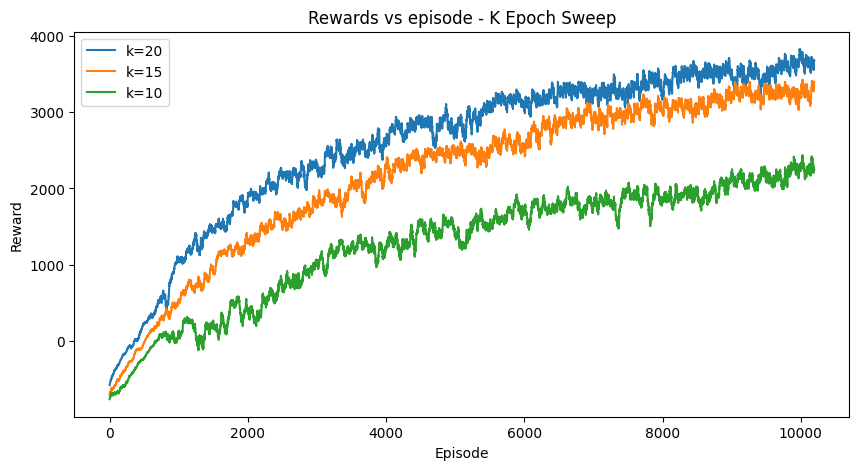

In [6]:
# plot k epochs runs
plt.figure(figsize=(10, 5))

for run in k_runs:
    plt.plot(smooth(run['rewards']), label=f"k={run['k_epochs']}")
plt.plot(smooth(base_run[0]['rewards']), label=f"k={base_run[0]['k_epochs']}")
plt.title(f"Rewards vs episode - K Epoch Sweep")
plt.xlabel("Episode")
plt.ylabel("Reward")
plt.legend()
plt.show()


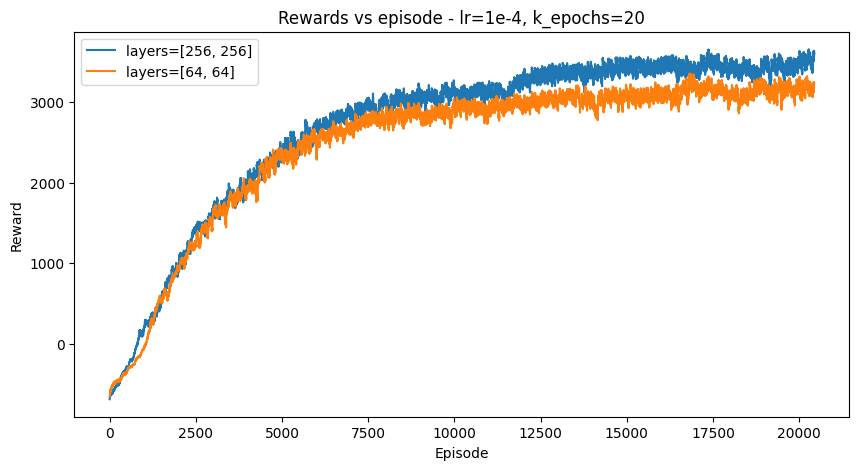

In [ ]:
# plot candidate runs
plt.figure(figsize=(10, 5))

for run in best_runs:
    plt.plot(smooth(run['rewards']), label=f"layers={run['actor_layer_sizes'][1:-1]}")
plt.title(f"Rewards vs episode - lr=1e-4, k_epochs=20")
plt.xlabel("Episode")
plt.ylabel("Reward")
plt.legend()
plt.show()


In [8]:
best_run = max(runs, key=lambda r: np.mean(r['rewards'][-100:]))
print(f"Best config: lr={best_run['lr']}, layers={best_run['actor_layer_sizes']}, k={best_run['k_epochs']}")
print(f"Final avg reward: {np.mean(best_run['rewards'][-100:]):.2f}")

Best config: lr=0.0003, layers=[17, 256, 256, 6], k=20
Final avg reward: 3632.61


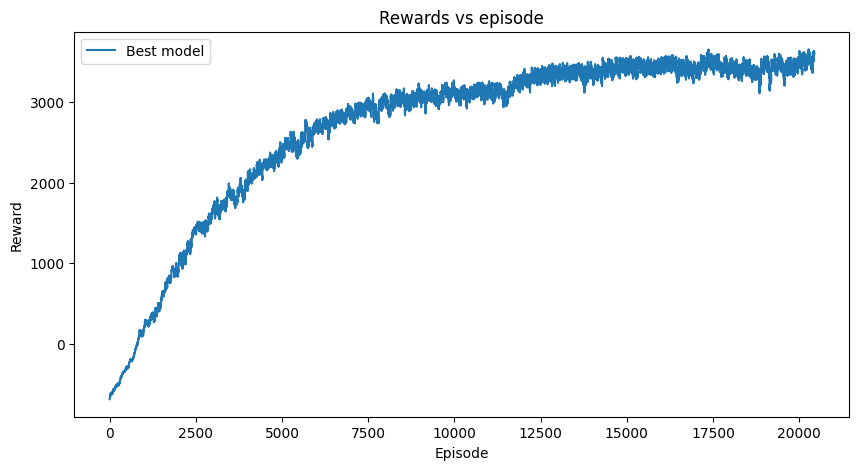

In [16]:
# Final plot for saving
plt.figure(figsize=(10, 5))

for run in best_runs:
    if run["actor_layer_sizes"][1:-1] == [256, 256]:
        plt.plot(smooth(run['rewards']), label=f"Best model")
plt.title(f"Rewards vs episode")
plt.xlabel("Episode")
plt.ylabel("Reward")
plt.legend()
save_dir = os.path.join(root_dir, "notebooks/training_curve.png")
plt.savefig(save_dir, dpi=150, bbox_inches='tight')
plt.show()
